## Pandas
- Series : 단일 데이터 열과 인덱스(index)로 구성된 1차원 구조체
- DataFrame : 행 인덱스와 열 이름(Columns)을 가진 2차원 표 구조체

In [1]:
import pandas as pd

scores = pd.Series([90,85,88])

print(scores)

0    90
1    85
2    88
dtype: int64


In [2]:
data = {
    '이름':['김철수','이영희','박지민'],
    '부서':['개발','기획','개발'],
    '급여':[4500,5200,4800]
}
df = pd.DataFrame(data)

df.info() # index와 컬럼 목록, 널이 아닌 데이터 수, 데이터 타입등 데이터 프레임의 요약 Non-Null Count는 널 찾는데도 쓴다
df.describe() # 데이터의 기초 통계, 평균, 최소값, 최고값 등을 보여준다

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   이름      3 non-null      str  
 1   부서      3 non-null      str  
 2   급여      3 non-null      int64
dtypes: int64(1), str(2)
memory usage: 204.0 bytes


,급여
count,3.000000
mean,4833.333333
std,351.188458
min,4500.000000
25%,4650.000000
50%,4800.000000
75%,5000.000000
max,5200.000000


In [3]:
# 열 추가 및 수정
df['보너스'] = df['급여'] *0.1 #급여에 0.1 배를 한 값들로 보너스 컬럼을 추가한

print(df)

    이름  부서    급여    보너스
0  김철수  개발  4500  450.0
1  이영희  기획  5200  520.0
2  박지민  개발  4800  480.0


### loc 와 iloc
- loc : 행의 이름으로 검색
    - loc[행 라벨]
    - loc[행 라벨, 컬럼 이름]
    - loc[시작행:종료행, [컬럼1,컬럼2,...]]
    - loc[..., 시작컬럼:종료컬럼]

- iloc : 숫자 인덱스로 검색
    - loc와 사용 방법은 동일하지만 행 라벨을 인덱스로 변경

In [4]:
df = pd.DataFrame({
    '나이': [25,30,35,40],
    '점수': [80,95,70,85],
    '등급': ['B','A','C','B']
}, index = ['user1','user2','user3','user4'])

df

,나이,점수,등급
user1,25,80,B
user2,30,95,A
user3,35,70,C
user4,40,85,B


In [5]:
df.loc['user1'], type(df.loc['user1']) # user1 의 로우 데이터 출력

(나이    25
 점수    80
 등급     B
 Name: user1, dtype: object,
 pandas.Series)

In [6]:
df.loc['user1':'user2', ['점수','등급']] # 행 부분은 []로 감싸지 않는다 : 를 썻기 때문
df.loc['user1':'user2','점수':'등급'] # 열에도 : 쓰면 마찬가지

,점수,등급
user1,80,B
user2,95,A


In [7]:
(df['나이'] >= 30) & (df['점수']>=80) # 각 index에서 조건에 해당하는 true, false를 반환한다
df[(df['나이'] >= 30) & (df['점수']>=80)] # df[] 로 위 조건에 맞는 데이터를 반환한다


,나이,점수,등급
user2,30,95,A
user4,40,85,B


In [8]:
df.query('나이 >= 30 and 점수 >= 80') # query 필터링을 사용해서 할 수 있다

,나이,점수,등급
user2,30,95,A
user4,40,85,B


### 결측치 탐지 및 처리
- info()
- isna(),isnull() : 같은 기능으로 차이가 없다 isna() 를 많이 쓴다

In [9]:
import numpy as np

# 결측치 - np.nan, pd.NA, NONE

raw_df = pd.DataFrame({'A': [1, np.nan, 3], 'B': [pd.NA, 5, 6], 'C': [7, 8, 9]})

raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       2 non-null      float64
 1   B       2 non-null      object 
 2   C       3 non-null      int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 204.0+ bytes


In [10]:
True + True #파이썬에서 True 는 1 False 는 0으로 숫자 사칙 연산에도 이용할 수 있다 

2

In [11]:
raw_df.isna() # 결측치(null) 이면 true를 반환한다

,A,B,C
0,False,True,False
1,True,False,False
2,False,False,False


In [12]:
raw_df.isna().sum() # true false를 다 더한다 true는 1이므로 각 컬럼에서 결측치의 개수를 알 수 있다

A    1
B    1
C    0
dtype: int64

In [13]:
raw_df.dropna() # 결측치가 있는 행을 삭제한다

,A,B,C
2,3.0,6,9


In [14]:
raw_df.dropna(axis=1) # 결측치가 있는 열을 삭제한다 (기본은 0 이므로 위에서는 입력하지 않는다)

,C
0,7
1,8
2,9


In [15]:
df_age = pd.DataFrame({'나이': [20, 25, None, 30, 95]})

median_val = df_age['나이'].median()   # 나이 열의 중앙값을 변수에 저장한다
print('중앙값:',median_val)
#df_age['나이'] = df_age['나이'].fillna(median_val) # 비어있는(None)에 중앙값을 입력한다

중앙값: 27.5


In [16]:
#df_age.ffill() # 앞에 있는 값으로 채운다
df_age.bfill() # 뒤에 있는 값으로 채운다

,나이
0,20.0
1,25.0
2,30.0
3,30.0
4,95.0


In [ ]:
speed_df = pd.DataFrame({'속도': [10.0, None, None, 40.0]})

speed_df['속도'] = speed_df['속도'].interpolate(method='linear') # liniar -> 10, ? ? 40 -> 10 20 30 40 으로 자연스럽게 증가한 값으로 채움

speed_df

,속도
0,10.0
1,20.0
2,30.0
3,40.0


### 이상 기호 치환 및 수치형 변환
- replace() : 이상한 데이터를 교체
- pandas.to_numeirc(...): 숫자 자료형으로 변환

In [ ]:
survey_df = pd.DataFrame({'점수': [85,-999,'?',95]})

survey_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   점수      4 non-null      object
dtypes: object(1)
memory usage: 164.0+ bytes


In [19]:
survey_df.describe()

,점수
count,4
unique,4
top,85
freq,1


In [ ]:
survey_df['점수'] = survey_df['점수'].replace([-999,'?'],pd.NA) # -999, '?' 를 pd.NA 로 None로 전환

survey_df

,점수
0,85
1,<NA>
2,<NA>
3,95


In [ ]:
survey_df.info() # null 이 2개 생긴걸 볼 수 있다

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   점수      2 non-null      object
dtypes: object(1)
memory usage: 164.0+ bytes


In [ ]:
survey_df['점수'] = pd.to_numeric(survey_df['점수'],errors='coerce') # to_numeric 로 값들을 숫자형으로 전환

survey_df.info() #Dtype 이 object 에서 float64로 바뀐걸 볼 수 있다

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   점수      2 non-null      float64
dtypes: float64(1)
memory usage: 164.0 bytes


In [ ]:
user_df = pd.DataFrame({'소득': [300, None, 450, None]})

user_df['미응답여부'] = user_df['소득'].isna() # 미응답여부 라는 새로운 컬럼을 생성하면서 값에 소득의 null 여부에 대해서 추가한다

user_df

,소득,미응답여부
0,300.0,False
1,NaN,True
2,450.0,False
3,NaN,True


In [25]:
sales_df = pd.DataFrame({'지점': ['서울', '서울', '부산', '부산'], '매출': [100, 150, 80, 120]})

sales_df

,지점,매출
0,서울,100
1,서울,150
2,부산,80
3,부산,120


In [ ]:
grouped_df = sales_df.groupby('지점').mean(numeric_only=True) # 지점을 기으로 숫자만 평균내서

grouped_df

,매출
지점,
부산,100.0
서울,125.0


## Matplotlib 기초
### 1. 캔버스(Figure)와 축(Axes) 기본 구조(fig, ax)
- 산점도: 데이터의 분포
- 꺽은선 그래프 : 시계열 데이터의 흐름
- 히스토그램: 데이터의 빈도수
- 박스 플롯: 이상치의 분포

- 캔버스 생성 - plt.feature(figsize(..)) - 1개를 그릴때 plt.subplots(행,열,figsize=(...))
- figsize: 캔버스의 크기 (가로인치, 세로인치)

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("titanic")

#df.iloc[:5]
#df[:5]
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [31]:
mode_embarked = df['embark_town'].mode()[0]

mode_embarked

'Southampton'

In [34]:
df['embark_town'] = df['embark_town'].fillna(mode_embarked)
df['embarked'] = df['embark_town'].map(lambda x:x[0].upper())

df['embarked']

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: embarked, Length: 891, dtype: str

In [35]:
import platform
from matplotlib import rc

os_name = platform.system()
if os_name == "Windows":
    rc("font", family="Malgun Gothic")
else:
    rc("font", family="AppleGothic")

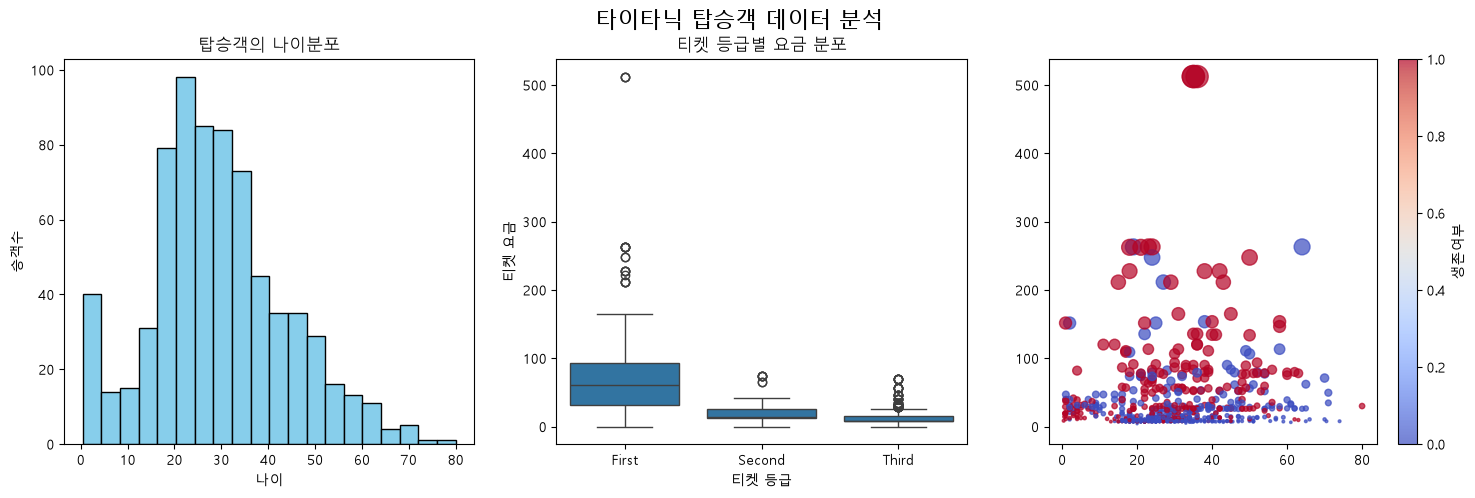

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('타이타닉 탑승객 데이터 분석', fontsize=16)

# [히스토그램] 탑승객 나이 분포
axes[0].hist(df['age'], bins=20, color='skyblue', edgecolor='black')
axes[0].set_title("탑승객의 나이분포")
axes[0].set_xlabel('나이')
axes[0].set_ylabel('승객수')

# [박스 플롯] 티켓 등급에 따른 요금 이상치 확인
sns.boxplot(x='class', y='fare', data=df, ax=axes[1])
axes[1].set_title('티켓 등급별 요금 분포')
axes[1].set_xlabel('티켓 등급')
axes[1].set_ylabel('티켓 요금')

# [산점도] 나이와 클리닝된 요금의 관계
scatter = axes[2].scatter(
    df['age'],
    df['fare'],
    c=df['survived'], # 1 - 빨강, 0 - 파랑
    cmap='coolwarm',
    s=df['fare'] / 2,
    alpha=0.7
)

fig.colorbar(scatter, ax=axes[2], label="생존여부")